#### Experiment 1 - Arrow's Theorem

In [1]:
import itertools
from math import comb

ALTS = (0, 1, 2)  # 3 alternatives
PAIRS = [(0,1), (0,2), (1,2)]

def all_linear_orders(m=3):
    return list(itertools.permutations(range(m)))

ORDERS = all_linear_orders(3)

def pair_pref(order, a, b):
    # returns 1 if a ranked above b
    return int(order.index(a) < order.index(b))

def profile_pair_vector(profile, a, b):
    # profile = tuple of voter orders
    return tuple(pair_pref(vote, a, b) for vote in profile)

def truth_table_eval(tt_int, x_bits):
    """
    tt_int encodes a boolean function on {0,1}^n.
    x_bits is tuple length n.
    Index x as binary number.
    """
    idx = 0
    for bit in x_bits:
        idx = (idx << 1) | bit
    return (tt_int >> idx) & 1

def social_pair(rule_tables, profile, a, b):
    # rule_tables[(a,b)] is integer truth table
    x = profile_pair_vector(profile, a, b)
    return truth_table_eval(rule_tables[(a,b)], x)

def is_transitive_from_pairs(s01, s02, s12):
    """
    For m=3, transitivity <=> not having a cycle.
    Represent sAB=1 means A>B socially.
    For pairs (0,1), (0,2), (1,2).
    A cycle occurs if 0>1, 1>2, 2>0 or the reverse.
    """
    # Build directed edges
    # 0 vs 1
    e01 = (0,1) if s01==1 else (1,0)
    e02 = (0,2) if s02==1 else (2,0)
    e12 = (1,2) if s12==1 else (2,1)

    edges = {e01, e02, e12}

    # Check if there's a 3-cycle
    cycle1 = {(0,1),(1,2),(2,0)}
    cycle2 = {(1,0),(2,1),(0,2)}
    return not (edges == cycle1 or edges == cycle2)

def pareto_ok(rule_tables, n):
    # Pareto: if all voters prefer a>b, society must prefer a>b
    for (a,b) in PAIRS:
        unanimous_1 = tuple([1]*n)
        unanimous_0 = tuple([0]*n)
        if truth_table_eval(rule_tables[(a,b)], unanimous_1) != 1:
            return False
        if truth_table_eval(rule_tables[(a,b)], unanimous_0) != 0:
            return False
    return True

def is_dictatorship(rule_tables, n):
    # Dictatorship means: there exists voter i s.t. for every pair and every x, f(x)=x[i]
    for i in range(n):
        ok = True
        for (a,b) in PAIRS:
            tt = rule_tables[(a,b)]
            for x in itertools.product([0,1], repeat=n):
                if truth_table_eval(tt, x) != x[i]:
                    ok = False
                    break
            if not ok:
                break
        if ok:
            return True
    return False

def run_bruteforce(n=2):
    profiles = list(itertools.product(ORDERS, repeat=n))

    total_iia_rules = 0
    pareto_survive = 0
    transitive_survive = 0
    transitive_and_pareto = 0
    dictators = 0

    # enumerate truth tables for each pair: 0..(2^(2^n)-1)
    tt_space = range(2 ** (2**n))

    for tt01 in tt_space:
        for tt02 in tt_space:
            for tt12 in tt_space:
                total_iia_rules += 1
                rule_tables = {(0,1): tt01, (0,2): tt02, (1,2): tt12}

                p_ok = pareto_ok(rule_tables, n)
                if p_ok:
                    pareto_survive += 1

                # check transitivity across all profiles
                t_ok = True
                for prof in profiles:
                    s01 = social_pair(rule_tables, prof, 0, 1)
                    s02 = social_pair(rule_tables, prof, 0, 2)
                    s12 = social_pair(rule_tables, prof, 1, 2)
                    if not is_transitive_from_pairs(s01, s02, s12):
                        t_ok = False
                        break

                if t_ok:
                    transitive_survive += 1
                if p_ok and t_ok:
                    transitive_and_pareto += 1
                    if is_dictatorship(rule_tables, n):
                        dictators += 1

    return {
        "total_iia_rules": total_iia_rules,
        "pareto_survive": pareto_survive,
        "transitive_survive": transitive_survive,
        "pareto_and_transitive": transitive_and_pareto,
        "dictators_among_pareto_and_transitive": dictators,
    }

results = run_bruteforce(n=2)
print(results)


{'total_iia_rules': 4096, 'pareto_survive': 64, 'transitive_survive': 94, 'pareto_and_transitive': 2, 'dictators_among_pareto_and_transitive': 2}


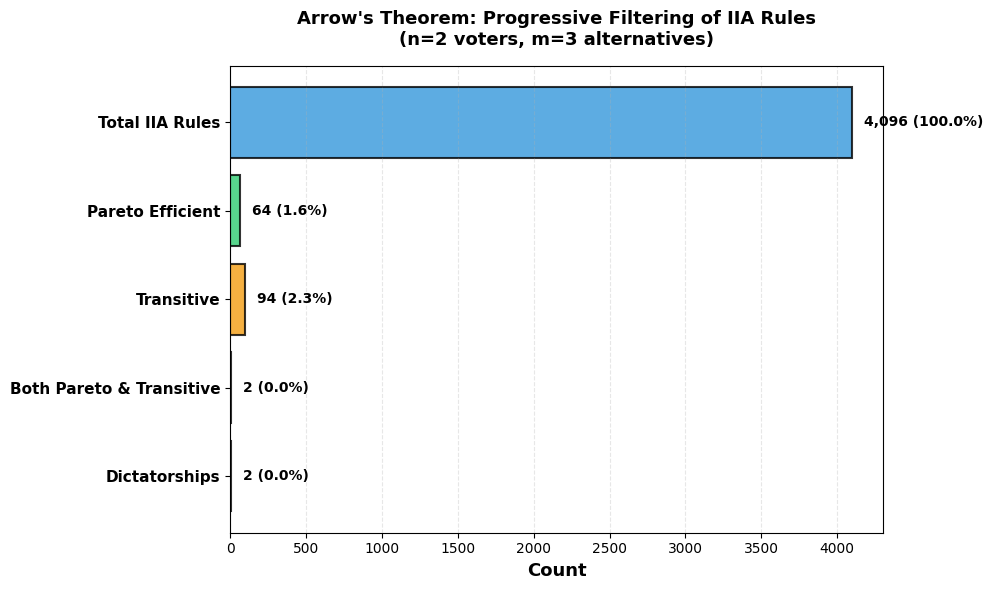


SUMMARY STATISTICS
Total IIA rules examined: 4,096

Pareto efficient rules: 64 (1.56%)
Transitive rules: 94 (2.29%)
Rules satisfying BOTH: 2 (0.05%)

Dictatorships among P&T rules: 2
Percentage of P&T rules that are dictatorships: 100.00%


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Create single panel visualization - funnel chart
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Funnel chart showing progressive filtering
funnel_data = [
    ('Total IIA Rules', results['total_iia_rules']),
    ('Pareto Efficient', results['pareto_survive']),
    ('Transitive', results['transitive_survive']),
    ('Both Pareto & Transitive', results['pareto_and_transitive']),
    ('Dictatorships', results['dictators_among_pareto_and_transitive'])
]

funnel_labels = [x[0] for x in funnel_data]
funnel_values = [x[1] for x in funnel_data]
funnel_colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']

# Calculate percentages relative to total
percentages = [(v/funnel_values[0])*100 for v in funnel_values]

y_pos = np.arange(len(funnel_labels))
bars = ax.barh(y_pos, funnel_values, color=funnel_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_labels, fontsize=11, fontweight='bold')
ax.set_xlabel('Count', fontsize=13, fontweight='bold')
ax.set_title('Arrow\'s Theorem: Progressive Filtering of IIA Rules\n(n=2 voters, m=3 alternatives)', 
              fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()  # Funnel flows downward

# Add value labels with percentages
for i, (bar, val, pct) in enumerate(zip(bars, funnel_values, percentages)):
    width = bar.get_width()
    ax.text(width + max(funnel_values)*0.02, bar.get_y() + bar.get_height()/2.,
             f'{int(val):,} ({pct:.1f}%)',
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total IIA rules examined: {results['total_iia_rules']:,}")
print(f"\nPareto efficient rules: {results['pareto_survive']:,} ({results['pareto_survive']/results['total_iia_rules']*100:.2f}%)")
print(f"Transitive rules: {results['transitive_survive']:,} ({results['transitive_survive']/results['total_iia_rules']*100:.2f}%)")
print(f"Rules satisfying BOTH: {results['pareto_and_transitive']:,} ({results['pareto_and_transitive']/results['total_iia_rules']*100:.2f}%)")
print(f"\nDictatorships among P&T rules: {results['dictators_among_pareto_and_transitive']:,}")
if results['pareto_and_transitive'] > 0:
    print(f"Percentage of P&T rules that are dictatorships: {results['dictators_among_pareto_and_transitive']/results['pareto_and_transitive']*100:.2f}%")
print("="*60)

#### Experiment 2 - Gibbard-Satterthwaite (strategy-proofness stress test)
We estimate how often common deterministic, onto rules are manipulable when a single voter misreports. Under Gibbard-Satterthwaite (m ≥ 3), any non-dictatorial, onto, strategy-proof rule must be a dictatorship. We show dictatorships have ~0 manipulation rate, while standard rules have positive rates.

Gibbard-Satterthwaite stress test: n in [5, 9], m=4, trials=220
n= 5 | Plurality            -> manip rate 0.423
n= 5 | Borda                -> manip rate 0.486
n= 5 | Copeland             -> manip rate 0.286
n= 5 | IRV                  -> manip rate 0.177
n= 5 | Two-round runoff     -> manip rate 0.200
n= 5 | Dictatorship (voter 1) -> manip rate 0.000
n= 9 | Plurality            -> manip rate 0.441
n= 9 | Borda                -> manip rate 0.445
n= 9 | Copeland             -> manip rate 0.273
n= 9 | IRV                  -> manip rate 0.236
n= 9 | Two-round runoff     -> manip rate 0.177
n= 9 | Dictatorship (voter 1) -> manip rate 0.000


C:\Users\corbi\AppData\Local\Temp\ipykernel_24028\3507428490.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')
C:\Users\corbi\AppData\Local\Temp\ipykernel_24028\3507428490.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')


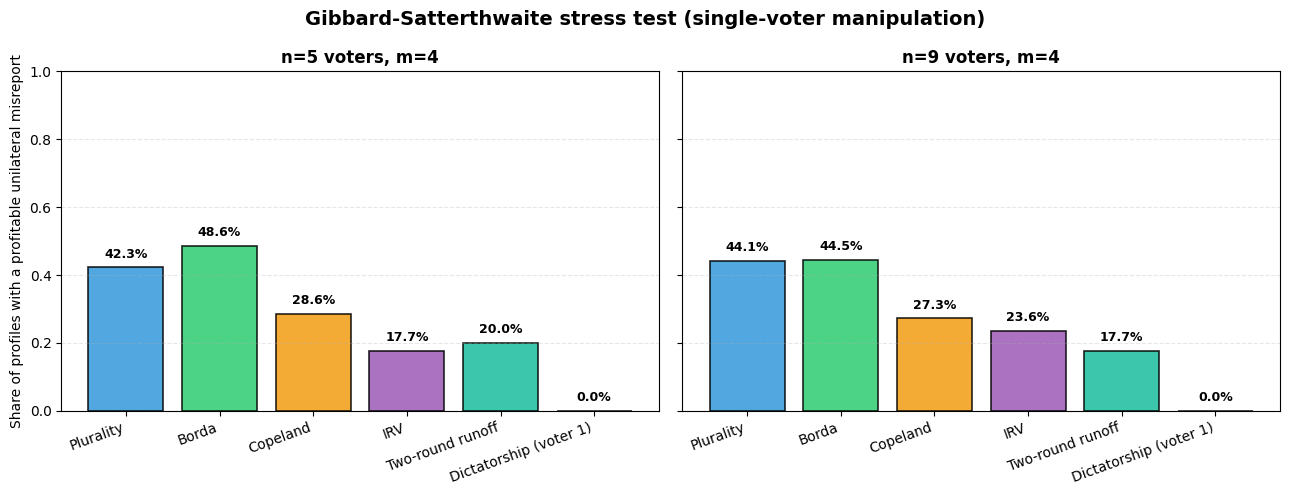


Interpretation: Dictatorships should be strategy-proof (rate ~0), while every non-dictatorial deterministic onto rule exhibits manipulability, illustrating the Gibbard-Satterthwaite impossibility.


In [7]:
import itertools
import random
from collections import Counter
import matplotlib.pyplot as plt

# Strategy-proofness helper

def prefers_sp(ballot, a, b):
    return ballot.index(a) < ballot.index(b)

def generate_profile(n_voters, alts, rng):
    return [tuple(rng.sample(alts, len(alts))) for _ in range(n_voters)]

# Voting rules returning a single winner (deterministic, tie-broken by label)

def plurality_winner_sp(profile, alts):
    counts = Counter(b[0] for b in profile)
    return min(alts, key=lambda x: (-counts[x], x))

def borda_winner_sp(profile, alts):
    m = len(alts)
    scores = Counter({a: 0 for a in alts})
    for ballot in profile:
        for rank, cand in enumerate(ballot):
            scores[cand] += (m - 1 - rank)
    return min(alts, key=lambda x: (-scores[x], x))

def copeland_winner_sp(profile, alts):
    score = Counter({a: 0.0 for a in alts})
    for i in range(len(alts)):
        for j in range(i + 1, len(alts)):
            a, b = alts[i], alts[j]
            a_votes = sum(1 for ballot in profile if prefers_sp(ballot, a, b))
            b_votes = len(profile) - a_votes
            if a_votes > b_votes:
                score[a] += 1.0
            elif b_votes > a_votes:
                score[b] += 1.0
            else:
                score[a] += 0.5
                score[b] += 0.5
    return min(alts, key=lambda x: (-score[x], x))

def irv_winner_sp(profile, alts):
    remaining = set(alts)
    ballots = [list(b) for b in profile]

    while len(remaining) > 1:
        counts = Counter()
        for b in ballots:
            for choice in b:
                if choice in remaining:
                    counts[choice] += 1
                    break
        total = sum(counts.values())
        for cand in remaining:
            if counts[cand] * 2 > total:
                remaining = {cand}
                break
        if len(remaining) == 1:
            break
        min_count = min(counts[c] for c in remaining)
        losers = [c for c in remaining if counts[c] == min_count]
        elim = min(losers)
        remaining.remove(elim)
    return next(iter(remaining))

def trs_winner_sp(profile, alts):
    counts = Counter(b[0] for b in profile)
    ranking = sorted(alts, key=lambda x: (-counts[x], x))
    a, b = ranking[0], ranking[1]
    a_votes = sum(1 for ballot in profile if prefers_sp(ballot, a, b))
    b_votes = len(profile) - a_votes
    winner = a if a_votes >= b_votes else b  # deterministic tie-break toward a if tie
    return winner

def dictator_winner_sp(profile, _alts, dictator_index=0):
    return profile[dictator_index][0]

# Manipulation checker

def is_manipulable(rule_fn, profile, alts):
    truthful_winner = rule_fn(profile, alts)
    for i, ballot in enumerate(profile):
        for misreport in itertools.permutations(alts):
            if misreport == ballot:
                continue
            prof2 = list(profile)
            prof2[i] = misreport
            new_winner = rule_fn(prof2, alts)
            if prefers_sp(ballot, new_winner, truthful_winner):
                return True
    return False

def estimate_manipulation_rate(rule_fn, n_voters, m_alts, trials=300, seed=0):
    rng = random.Random(seed)
    alts = list(range(m_alts))
    manip = 0
    for _ in range(trials):
        profile = generate_profile(n_voters, alts, rng)
        if is_manipulable(rule_fn, profile, alts):
            manip += 1
    return manip / trials

# Run the Gibbard-Satterthwaite stress test

n_values = [5, 9]
m_alts = 4
trials = 220  # keep runtime reasonable

rules = {
    "Plurality": plurality_winner_sp,
    "Borda": borda_winner_sp,
    "Copeland": copeland_winner_sp,
    "IRV": irv_winner_sp,
    "Two-round runoff": trs_winner_sp,
    "Dictatorship (voter 1)": lambda P, A: dictator_winner_sp(P, A, dictator_index=0),
}

print(f"Gibbard-Satterthwaite stress test: n in {n_values}, m={m_alts}, trials={trials}")
results_gs = {n: {} for n in n_values}
for n in n_values:
    for name, fn in rules.items():
        rate = estimate_manipulation_rate(fn, n, m_alts, trials=trials, seed=1000 + n)
        results_gs[n][name] = rate
        print(f"n={n:2d} | {name:20s} -> manip rate {rate:.3f}")

# Plot results
fig, axes = plt.subplots(1, len(n_values), figsize=(13, 5), sharey=True)
fig.suptitle("Gibbard-Satterthwaite stress test (single-voter manipulation)", fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e74c3c']
for ax, n in zip(axes, n_values):
    labels = list(rules.keys())
    vals = [results_gs[n][label] for label in labels]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
    ax.set_ylim(0, 1)
    ax.set_title(f"n={n} voters, m={m_alts}", fontsize=12, fontweight='bold')
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_ylabel("Share of profiles with a profitable unilateral misreport")
plt.tight_layout()
plt.show()

print("\nInterpretation: Dictatorships should be strategy-proof (rate ~0), while every non-dictatorial deterministic onto rule exhibits manipulability, illustrating the Gibbard-Satterthwaite impossibility.")

#### Experiment 3 - Coalition Manipulation Depth (GS extension)
We estimate how large a coalition must be to profitably manipulate common rules. For each rule and profile, we search coalition sizes 1..3. A coalition is counted successful if all its members strictly prefer the new winner to the truthful winner. We report: (a) manipulation rate by coalition size, and (b) share of profiles where the minimal successful coalition has size 1, 2, 3, or none (strategy-proof at tested depths).

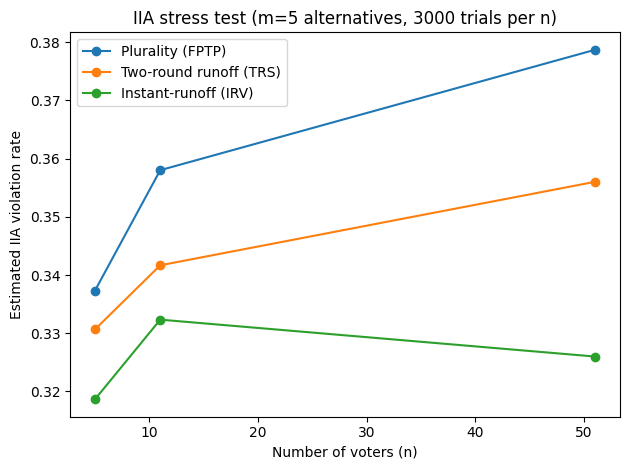

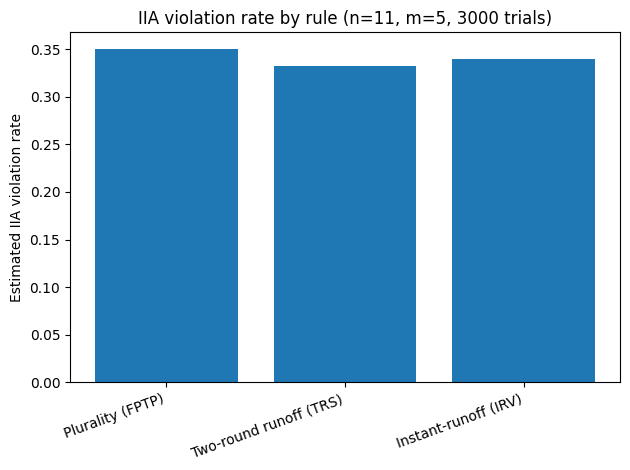

In [3]:
import random
import itertools
from collections import Counter
import matplotlib.pyplot as plt

# ---------------------------
# Utilities: profiles & ranking
# ---------------------------

def random_profile(n_voters, alts, rng=random):
    """Return a profile: list of ballots (each ballot is a tuple ranking)."""
    alts = list(alts)
    return [tuple(rng.sample(alts, len(alts))) for _ in range(n_voters)]

def prefers(ballot, a, b):
    """True if ballot ranks a above b."""
    return ballot.index(a) < ballot.index(b)

def preserve_pair_randomize_rest(ballot, a, b, rng=random):
    """
    Return a new ballot that keeps the relative order between a and b the same,
    while randomizing positions of all other alternatives.
    """
    rest = [x for x in ballot if x not in (a, b)]
    rng.shuffle(rest)

    # Keep a vs b order
    if prefers(ballot, a, b):
        pair = [a, b]
    else:
        pair = [b, a]

    # Randomly interleave 'pair' into 'rest'
    # Choose 2 insertion positions among (len(rest)+2) slots (order fixed inside pair)
    slots = list(range(len(rest) + 2))
    i1, i2 = sorted(rng.sample(slots, 2))
    out = []
    r_idx = 0
    for pos in range(len(rest) + 2):
        if pos == i1:
            out.append(pair[0])
        elif pos == i2:
            out.append(pair[1])
        else:
            out.append(rest[r_idx])
            r_idx += 1
    return tuple(out)

def modified_profile_preserve_AB(profile, a, b, rng=random):
    return [preserve_pair_randomize_rest(ballot, a, b, rng) for ballot in profile]

# ---------------------------
# Rule 1: Plurality (FPTP)
# ---------------------------

def plurality_winner(profile, alts):
    counts = Counter(ballot[0] for ballot in profile)
    # Deterministic tie-break: smallest alt label
    return min(alts, key=lambda x: (-counts[x], x))

def plurality_rank(profile, alts):
    counts = Counter(ballot[0] for ballot in profile)
    return sorted(alts, key=lambda x: (-counts[x], x))

# ---------------------------
# Rule 2: Two-round runoff (TRS)
# ---------------------------

def top_two_by_plurality(profile, alts):
    counts = Counter(ballot[0] for ballot in profile)
    ranking = sorted(alts, key=lambda x: (-counts[x], x))
    return ranking[0], ranking[1]

def head_to_head_winner(profile, a, b):
    a_votes = sum(1 for ballot in profile if prefers(ballot, a, b))
    b_votes = len(profile) - a_votes
    if a_votes > b_votes:
        return a
    if b_votes > a_votes:
        return b
    return min(a, b)  # deterministic tie-break

def trs_winner(profile, alts):
    x, y = top_two_by_plurality(profile, alts)
    return head_to_head_winner(profile, x, y)

def trs_rank(profile, alts):
    # For IIA test we only need relative order A vs B,
    # so we define a full ranking using: winner first, then the rest by plurality.
    w = trs_winner(profile, alts)
    rest = [a for a in alts if a != w]
    # order rest by plurality counts for determinism (not "official TRS", but fine for A vs B comparisons)
    counts = Counter(ballot[0] for ballot in profile)
    rest_sorted = sorted(rest, key=lambda x: (-counts[x], x))
    return [w] + rest_sorted

# ---------------------------
# Rule 3: IRV (Instant-runoff / Alternative Vote)
# ---------------------------

def irv_winner(profile, alts):
    remaining = set(alts)
    ballots = [list(b) for b in profile]

    while True:
        # count first active choice
        counts = Counter()
        for b in ballots:
            for choice in b:
                if choice in remaining:
                    counts[choice] += 1
                    break

        total = sum(counts.values())
        # majority?
        for cand, c in counts.items():
            if c * 2 > total:
                return cand

        # eliminate lowest (deterministic tie-break)
        min_count = min(counts[c] for c in remaining)
        losers = [c for c in remaining if counts[c] == min_count]
        elim = min(losers)
        remaining.remove(elim)

        if len(remaining) == 1:
            return next(iter(remaining))

def irv_rank(profile, alts):
    # Produce a ranking by elimination order: winner first, then reverse of eliminations.
    remaining = set(alts)
    ballots = [list(b) for b in profile]
    eliminated = []

    while len(remaining) > 1:
        counts = Counter()
        for b in ballots:
            for choice in b:
                if choice in remaining:
                    counts[choice] += 1
                    break
        min_count = min(counts[c] for c in remaining)
        losers = [c for c in remaining if counts[c] == min_count]
        elim = min(losers)
        eliminated.append(elim)
        remaining.remove(elim)

    winner = next(iter(remaining))
    return [winner] + list(reversed(eliminated))

# ---------------------------
# IIA violation estimator
# ---------------------------

def rule_prefers_A_over_B(rule_rank_fn, profile, alts, A, B):
    ranking = rule_rank_fn(profile, alts)
    # ranking is list ordered best->worst
    return ranking.index(A) < ranking.index(B)

def estimate_iia_violation_rate(rule_rank_fn, n_voters, m_alts, trials=5000, seed=0):
    rng = random.Random(seed)
    alts = list(range(m_alts))

    flips = 0
    total = 0

    for _ in range(trials):
        profile = random_profile(n_voters, alts, rng)
        A, B = rng.sample(alts, 2)

        before = rule_prefers_A_over_B(rule_rank_fn, profile, alts, A, B)

        profile2 = modified_profile_preserve_AB(profile, A, B, rng)
        after = rule_prefers_A_over_B(rule_rank_fn, profile2, alts, A, B)

        if before != after:
            flips += 1
        total += 1

    return flips / total

def run_experiment():
    rules = {
        "Plurality (FPTP)": plurality_rank,
        "Two-round runoff (TRS)": trs_rank,
        "Instant-runoff (IRV)": irv_rank,
    }

    trials = 3000
    m_alts = 5
    voter_sizes = [5, 11, 51]

    results = {name: [] for name in rules}
    for n in voter_sizes:
        for name, fn in rules.items():
            rate = estimate_iia_violation_rate(fn, n, m_alts, trials=trials, seed=123 + n)
            results[name].append(rate)

    # Plot: IIA violation vs voters
    plt.figure()
    for name in rules:
        plt.plot(voter_sizes, results[name], marker="o", label=name)
    plt.xlabel("Number of voters (n)")
    plt.ylabel("Estimated IIA violation rate")
    plt.title(f"IIA stress test (m={m_alts} alternatives, {trials} trials per n)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot: bar chart at a single n for quick comparison
    n0 = 11
    bar_rates = []
    for name, fn in rules.items():
        bar_rates.append(estimate_iia_violation_rate(fn, n0, m_alts, trials=trials, seed=999))

    plt.figure()
    plt.bar(list(rules.keys()), bar_rates)
    plt.ylabel("Estimated IIA violation rate")
    plt.title(f"IIA violation rate by rule (n={n0}, m={m_alts}, {trials} trials)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment()